TOMORROW SCREEN RECORD WHILE LIVE IMAGING ON ATLAS

There are sevaral places where improvement is required. 

First, the pyautogui.locate requires an image input, so you can't just give it text to find on the screen. If you want that, you need a more sophisticated method. Or just know it has limited transferability across systems. 

- I think the way to do this would be to use the snapshot feature with a live cropping GUI to save the reference image (used to find imaging fov on screen).

- update get_title() function to allow user to select refernece image. 
- update live gui view
- save screen recording as npy
- convert npy to mp4 for viewing

In [2]:
#WHENEVER U HAQVE CV2 PROBLEMS RUN THIS INSTEAD OF RESTARTING EKRNEL
cv2.destroyAllWindows()

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pyautogui
from PIL import Image
import os
from tkinter import Tk
from tkinter.filedialog import askdirectory
from datetime import datetime
import threading
import nidaqmx 
import time
from pynput import keyboard
from queue import Queue
from collections import deque

### test threading integration

In [84]:
def calculate_dff(current_F, F_buffer):
    """
    Calculate dF/F using rolling window baseline
    
    Args:
        current_F: Current frame's mean intensity
        F_buffer: deque containing recent F values
    
    Returns:
        float: dF/F value
    """
    # Calculate baseline (F0) from buffer, excluding current value
    F0 = np.mean(list(F_buffer)[:-1]) if len(F_buffer) > 1 else current_F
    
    # Calculate dF/F
    dff = (current_F - F0) / F0 if F0 != 0 else 0
    return dff

def analysis_worker(frame_queue, trigger_queue, window_size=20, event_threshold=0.2):
    """
    Worker thread for dF/F calculation and event detection
    
    Args:
        frame_queue: Queue receiving frames from screen recording
        trigger_queue: Queue to send trigger requests to NIDAQ
        window_size: Size of rolling window for baseline
        event_threshold: Threshold for event detection
    """
    # Initialize rolling buffer for F values
    F_buffer = deque(maxlen=window_size)
    
    while True:
        # Get frame from queue
        frame = frame_queue.get()
        
        # Check for stop signal
        if frame is None:
            print("Analysis worker received stop signal")
            break
            
        try:
            # Calculate mean intensity
            current_F = np.mean(frame)
            
            # Add to buffer
            F_buffer.append(current_F)
            
            # Calculate dF/F if buffer has enough frames
            if len(F_buffer) >= window_size:
                dff = calculate_dff(current_F, F_buffer)
                
                # Event detection
                if dff > event_threshold:
                    print(f"Event detected! dF/F = {dff:.3f}")
                    trigger_queue.put(True)  # Request NIDAQ pulse
                    
        except Exception as e:
            print(f"Error in analysis worker: {e}")

def live_screen_record_with_analysis(fov, window_size=20, event_threshold=0.2, 
                                   card_id='Dev1', port_line='port1/line0',
                                   display_live=True):
    """
    Record screen with real-time analysis and NIDAQ output
    """
    global live
    live = True
    frames = []
    
    # Initialize queues
    frame_queue = Queue()    # For sending frames to analysis
    trigger_queue = Queue()  # For sending triggers to NIDAQ
    
    # Start NIDAQ worker thread
    nidaq_thread = threading.Thread(
        target=nidaq_worker, 
        args=(trigger_queue, card_id, port_line)
    )
    nidaq_thread.start()
    
    # Start analysis worker thread
    analysis_thread = threading.Thread(
        target=analysis_worker,
        args=(frame_queue, trigger_queue, window_size, event_threshold)
    )
    analysis_thread.start()
    
    # Start keyboard monitoring thread
    key_thread = threading.Thread(target=key_monitor)
    key_thread.daemon = True
    key_thread.start()
    
    try:
        while live:
            # Capture frame
            img = pyautogui.screenshot(region=(
                fov['x'], fov['y'], fov['width'], fov['height']
            ))
            np_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
            
            # Send frame to analysis thread
            frame_queue.put(np_img)
            
            if display_live:
                cv2.imshow('Screen Recording', np_img)
                cv2.waitKey(1)
            
            frames.append(np_img)
            
    except Exception as e:
        print(f"Error in recording: {e}")
        
    finally:
        # Cleanup
        cv2.destroyAllWindows()
        
        # Stop worker threads
        frame_queue.put(None)    # Stop analysis thread
        trigger_queue.put(None)  # Stop NIDAQ thread
        
        analysis_thread.join()
        nidaq_thread.join()
        
        print("Recording stopped, workers cleaned up")
        
        return frames

In [88]:
# Get FOV
filename, save_directory, data_filepath = get_save_info()
fov = get_fov(save_dir=save_directory, filename=filename)

# Start recording with analysis
frames = live_screen_record_with_analysis(
    fov,
    window_size=20,          # Adjust based on your needs
    event_threshold=0.2,     # Adjust based on your needs
    card_id='Dev1',
    port_line='port1/line0',
    display_live=True
)

NIDAQ task created on Dev1/port1/line0
Event detected! dF/F = 0.731
Event detected! dF/F = 0.620
Event detected! dF/F = 0.425
Event detected! dF/F = 0.272
Event detected! dF/F = 0.230
Event detected! dF/F = 0.206
Event detected! dF/F = 0.343
Event detected! dF/F = 0.251
Event detected! dF/F = 0.293
Event detected! dF/F = 0.948
Event detected! dF/F = 0.981
Event detected! dF/F = 0.521
Event detected! dF/F = 0.428
Event detected! dF/F = 0.529
Event detected! dF/F = 0.376
Event detected! dF/F = 0.284
Event detected! dF/F = 0.296
Event detected! dF/F = 0.289
Event detected! dF/F = 0.248
Event detected! dF/F = 0.227
Event detected! dF/F = 0.276
Event detected! dF/F = 0.726
Event detected! dF/F = 0.979
Event detected! dF/F = 0.918
Event detected! dF/F = 0.842
Event detected! dF/F = 0.742
Event detected! dF/F = 0.652
Event detected! dF/F = 0.519
Event detected! dF/F = 0.511
Event detected! dF/F = 0.460
Event detected! dF/F = 0.239
Event detected! dF/F = 0.330
Event detected! dF/F = 0.259
Even

### test nidaq here :p

okay putting nidaqmx into a thread seems to work, now we need to integrate with live screen recording. probably we need another global variable to track event_state

such that if event:
    trigger_queue.put(True)
    to trigger the solenoid to open! 

In [67]:
from queue import Queue

In [70]:
def nidaq_worker(trigger_queue, card_id='Dev1', port_line='port1/line0', pulse_duration=0.100):
    """
    Worker thread for handling NIDAQ digital output
    """
    with nidaqmx.Task() as task:
        task.do_channels.add_do_chan(f"{card_id}/{port_line}")
        print(f"NIDAQ task created on {card_id}/{port_line}")
        
        while True:
            # Block here until a message is received
            trigger = trigger_queue.get()
            
            # Exit condition: if None is received
            if trigger is None:
                print("NIDAQ worker received stop signal")
                break
            
            try:
                # Create pulse: True for 1ms, then False
                task.write(True)
                time.sleep(pulse_duration)  # 1ms pulse
                task.write(False)
            except Exception as e:
                print(f"Error in NIDAQ worker: {e}")


In [72]:
def test_nidaq_thread(card_id='Dev1', port_line='port1/line0', n_pulses=5, pulse_duration = 0.100, interval=0.5):
    """
    Test NIDAQ output with queue communication
    """
    # Initialize queue
    trigger_queue = Queue()
    
    # Start worker thread
    nidaq_thread = threading.Thread(
        target=nidaq_worker, 
        args=(trigger_queue, card_id, port_line, pulse_duration)
    )
    nidaq_thread.start()
    
    try:
        # Send test pulses through queue
        for i in range(n_pulses):
            print(f"Pulse {i+1}/{n_pulses}")
            trigger_queue.put(True)  # Request pulse
            time.sleep(interval)
    finally:
        # Stop worker thread
        trigger_queue.put(None)  # Send stop signal
        nidaq_thread.join()      # Wait for thread to finish

In [75]:
 test_nidaq_thread(card_id='Dev1', port_line='port1/line0', n_pulses=5, pulse_duration = 0.005, interval=0.5)

Pulse 1/5
NIDAQ task created on Dev1/port1/line0
Pulse 2/5
Pulse 3/5
Pulse 4/5
Pulse 5/5
NIDAQ worker received stop signal


In [ ]:
def send_digital_output(card_id='Dev1', port_line='port0/line0', signal_pattern=[True, False], signal_duration=1):
    """
    Sends a digital output signal to a specified pin on the NI DAQ.

    Args:
        card_id (str): The ID of the NI DAQ device (e.g., 'Dev1').
        port_line (str): The digital output line to control (e.g., 'port0/line0').
        signal_pattern (list): List of signal states (e.g., [1, 0]) to send.
        signal_duration (float): Duration (in seconds) for each state in the pattern.
    """
    try:
        # Create a task for digital output
        with nidaqmx.Task() as task:
            # Add the specified digital output channel
            task.do_channels.add_do_chan(f"{card_id}/{port_line}")

            print(f"Sending digital output to {card_id}/{port_line}...")

            # Send the signal pattern
            while True:
                for state in signal_pattern:
                    task.write(state)  # Write the digital state (1 for HIGH, 0 for LOW)
                    print(f"Set {port_line} to {'HIGH' if state else 'LOW'}")
                    time.sleep(signal_duration)  # Hold the state for the specified duration

            print("Digital output complete.")

    except Exception as e:
        print(f"Error sending digital output: {e}")

In [ ]:
send_digital_output(card_id='Dev1', port_line='port1/line0', signal_pattern=[True, False], signal_duration=0.01)

### Code to prompt user for filename and directory to save

In [6]:
#prompt user for filename
filename = input("Enter filename: ")
#open window to choose directory 
root = Tk()
root.withdraw()  # Hide the main tkinter window
save_directory = askdirectory(title="Select Directory to Save screenshot")
data_filename = f"{filename}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
data_filepath = os.path.join(save_directory, data_filename)

In [81]:
def get_save_info():
    """
    Prompts user for filename and directory selection.
    Returns:
        tuple: (filename, save_directory, data_filepath) where
            - filename: raw filename entered by user
            - save_directory: full path to selected directory
            - data_filepath: complete filepath including timestamp
    """
    # Prompt user for filename
    filename = input("Enter filename: ")
    
    # Open window to choose directory 
    root = Tk()
    root.withdraw()  # Hide the main tkinter window
    save_directory = askdirectory(title="Select Directory to Save")
    
    # Create timestamped filename
    data_filename = f"{filename}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    data_filepath = os.path.join(save_directory, data_filename)
    
    return filename, save_directory, data_filepath

In [17]:
filename, save_directory, data_filepath = get_save_info()

### Code to find the dropbox folder and path on any computer!
subfolder is written specifically to find snapshot_env

In [7]:
def get_dropbox_folder():
    '''returns the parent dropbox folder, should be os (mac/windows/linux) independent
    may need to remove (MIT), not sure if other computers have diff name for dropbox folder'''
    home_dir = os.path.expanduser("~")
    dropbox_folder = os.path.join(home_dir, "Dropbox (MIT)")
    return dropbox_folder

In [8]:
def get_dropbox_subfolder(subfolder_name):
    home_dir = os.path.expanduser("~")
    dropbox_folder = os.path.join(home_dir, "Dropbox (MIT)")
    subfolder_path = os.path.join(dropbox_folder, subfolder_name)
    return subfolder_path

subfolder_name = "Emma/Behavior_Code_Emma/snapshot_env"
snapshot_dir = get_dropbox_subfolder(subfolder_name)
print(f"Dropbox subfolder path: {snapshot_dir}")

Dropbox subfolder path: C:\Users\emma_odom\Dropbox (MIT)\Emma/Behavior_Code_Emma/snapshot_env


### Func to get pixel location, and crop a reference image used to locate fov on screen.

In [5]:
def get_pixel_location():
    """gets current pixel location of mouse on screen"""
    input("Move cursor to desired position, press enter")
    x, y = pyautogui.position()
    print(f"Pixel location: ({x}, {y})")
    return x, y

In [19]:
def get_fov(save_dir,filename='fov'):
    """pyautogui.position() gets current pixel location of mouse on screen
    user marks corners of desired field of view (fov) for screen recording"""
    
    input("Move cursor to TOP LEFT, press ENTER")
    # Move cursor to top left of fov
    x_tL, y_tL = pyautogui.position()
    
    input("Move cursor to BOTTOM RIGHT, press ENTER")
    # Move cursor to bottom right of fov
    x_bR, y_bR = pyautogui.position()

    # Get params for cropping
    width = x_bR - x_tL
    height = y_bR - y_tL

    # Crop
    fov = pyautogui.screenshot(region=(x_tL, y_tL, width, height))
    
    # Save, png required to use locateOnScreen
    fov = fov.convert('RGB')
    save_path = os.path.join(save_dir, f"{filename}.png")
    fov.save(save_path)

    # Display the cropped image
    fov.show()

    return {'x': x_tL, 'y': y_tL, 'width': width, 'height': height}


### integrate live dff 

okay this one pseudo works but we'll need to come back and implement threading

In [ ]:
def live_screen_record_with_events(fov, window_size=20, event_threshold=0.2, 
                                 display_live=True, save_frames=False, save_dir=False):
    """
    Record screen and perform real-time event detection with NIDAQ output
    
    Args:
        fov (dict): Dictionary containing x, y, width, height of recording region
        window_size (int): Size of rolling window for dF/F calculation
        event_threshold (float): Threshold for event detection
        display_live (bool): Whether to show live preview
        save_frames (bool): Whether to save the frames
        save_dir (str): Directory to save frames if save_frames is True
    """
    global live
    live = True
    frames = []
    
    # Initialize rolling window buffer for F values
    F_buffer = deque(maxlen=window_size)
    
    # Setup NIDAQ
    try:
        card = {
            'trigger_mode': 'out',
            'id': 'Dev1',
            'name': 'nidaq'
        }
        card['dio'] = nidaqmx.Task()
        card['dio'].do_channels.add_do_chan(
            'Dev1/port0/line1',
            line_grouping=LineGrouping.CHAN_PER_LINE
        )
        nidaq_available = True
    except Exception as e:
        print(f"NIDAQ setup failed: {e}")
        nidaq_available = False

    # Create and start the keyboard monitoring thread
    key_thread = threading.Thread(target=key_monitor)
    key_thread.daemon = True
    key_thread.start()

    try:
        # Main screen recording loop
        while live:
            # Capture frame and convert to grayscale
            img = pyautogui.screenshot(region=(fov['x'], fov['y'], fov['width'], fov['height']))
            np_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
            
            # Calculate current F value
            current_F = np.mean(np_img)
            F_buffer.append(current_F)
            
            # Calculate dF/F if we have enough frames
            if len(F_buffer) == window_size:
                F0 = np.mean(list(F_buffer)[:-1])  # Baseline from previous frames
                dff = (current_F - F0) / F0 if F0 != 0 else 0
                
                # Event detection
                if dff > event_threshold:
                    print(f"Event detected! dF/F = {dff:.3f}")
                    
                    # Send NIDAQ trigger
                    if nidaq_available:
                        try:
                            # Send trigger pulse
                            card['dio'].write([True], auto_start=True)
                            time.sleep(0.001)  # 1ms pulse
                            card['dio'].write([False], auto_start=True)
                        except Exception as e:
                            print(f"NIDAQ trigger failed: {e}")
                
                # Display frame with dF/F value
                if display_live:
                    display_img = np_img.copy()
                    cv2.putText(display_img, f'dF/F: {dff:.3f}', (10, 30), 
                              cv2.FONT_HERSHEY_SIMPLEX, 1, (255), 2)
                    cv2.imshow('Screen Recording', display_img)
                    cv2.waitKey(1)
            
            if save_frames:
                frames.append(np_img)

    except Exception as e:
        print(f"Error during recording: {e}")
    
    finally:
        # Cleanup
        cv2.destroyAllWindows()
        if nidaq_available:
            card['dio'].close()
        
        if save_frames and save_dir:
            frames_array = np.array(frames)
            save_path = os.path.join(save_dir, 
                                   f"recording_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npy")
            np.save(save_path, frames_array)
            print(f"Recording saved to: {save_path}")
        
        return frames if save_frames else None

# Usage example:
if __name__ == "__main__":
    # Get filename and directory
    filename, save_directory, data_filepath = get_save_info()
    
    # Get FOV
    fov = get_fov(save_dir=save_directory, filename=filename)
    
    # Start recording with event detection
    frames = live_screen_record_with_events(
        fov,
        window_size=20,          # Adjust based on your testing
        event_threshold=0.2,     # Adjust based on your testing
        display_live=True,
        save_frames=True,
        save_dir=save_directory
    )

### some checking cells

In [51]:
get_pixel_location()


Pixel location: (945, 270)


(945, 270)

In [52]:
fov = get_fov(save_dir = snapshot_dir)

In [58]:
fov['x']

1419

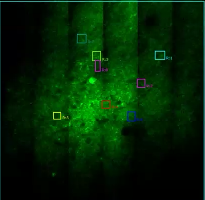

In [59]:
pyautogui.screenshot(region=(fov['x'],fov['y'],fov['width'],fov['height']))

In [101]:
#okay this shwos that the keyboard listener works
def test_pynput():
    """
    Test if pynput keyboard listener is working.
    Press 'q' to quit the test.
    """
    from pynput import keyboard
    print("Starting pynput test...")
    print("Press 'q' to quit")
    
    def on_press(key):
        try:
            print(f'Key pressed: {key.char}')
            if key.char == 'q':
                # Stop listener
                return False
        except AttributeError:
            print(f'Special key pressed: {key}')
    
    # Start keyboard listener
    with keyboard.Listener(on_press=on_press) as listener:
        listener.join()
    
    print("Test completed")

# Run the test
test_pynput()

Starting pynput test...
Press 'q' to quit
Key pressed: f
Key pressed: f
Key pressed: e
Key pressed: q
Test completed


### live screen record and threading of keyboard interrupt listener

on_press, key_monitor and live_screen_record just worked together!!

In [7]:
def on_press(key):
    """Callback function for key press"""
    global live
    try:
        if key.char == 'q':  
            live = False
    except AttributeError:
        pass 

def key_monitor():
    """Monitor keyboard input using pynput"""
    with keyboard.Listener(on_press=on_press) as listener:
        listener.join()

In [22]:
def live_screen_record(fov,display_live=True,save_frames=False,save_dir=False):
    """
    Record screen within specified field of view until 'q' or ESC is pressed
    
    Args:
        fov (dict): Dictionary containing x, y, width, height of recording region
        save_frames (bool): Whether to save the frames (optional)
        save_dir (str): Directory to save frames if save_frames is True (optional)
    """
    global live
    live = True
    frames=[]
    # Create and start the keyboard monitoring thread
    
    key_thread = threading.Thread(target=key_monitor)
    key_thread.daemon = True
    key_thread.start()

    # Main screen recording loop
    while live:
        img = pyautogui.screenshot(region=(fov['x'], fov['y'], fov['width'], fov['height']))
        np_img = np.array(img)
        
        if display_live:
            cv2.imshow('Screen Recording', np_img)
            cv2.waitKey(1)  
        
        if save_frames:
            frames.append(np_img)
    
    cv2.destroyAllWindows()
    
    if save_frames and save_dir:
        frames_array = np.array(frames)
        save_path = os.path.join(save_dir, f"recording_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npy")
        np.save(save_path, frames_array)
        print(f"Recording saved to: {save_path}")
        
    return frames_array if save_frames else None


In [43]:
#SCRIPT
filename, save_directory, data_filepath = get_save_path()
fov = get_fov(save_dir=save_directory,filename=filename)
frames = live_screen_record(fov, save_frames=True)

In [100]:
cv2.destroyAllWindows()

### working on dff code now!

functions to test rolling window size (Dff) and threshold (event detect) 

In [27]:
def calculate_frame_fluorescence(frames):
    """
    Calculate mean fluorescence for each frame
    
    Args:
        frames: numpy array of shape (n_frames, height, width)
    
    Returns:
        numpy array of mean fluorescence values for each frame
    """
    return np.mean(frames, axis=(1,2))

def calculate_dff_rolling(F, window_size, method='mean'):
    """
    Calculate dF/F using rolling window baseline
    
    Args:
        F: 1D array of fluorescence values
        window_size: Size of rolling window (in frames)
        method: 'mean' or 'median' for baseline calculation
    
    Returns:
        dff: dF/F trace
        F0: baseline trace
    """
    # Calculate rolling baseline
    if method == 'mean':
        F0 = pd.Series(F).rolling(window=window_size, center=True).mean()
    elif method == 'median':
        F0 = pd.Series(F).rolling(window=window_size, center=True).median()
    else:
        raise ValueError("Method must be 'mean' or 'median'")
    
    # Fill NaN values at edges with nearest non-NaN value
    F0 = F0.fillna(method='bfill').fillna(method='ffill')
    
    # Calculate dF/F
    dff = (F - F0) / F0
    
    return dff.values, F0.values

def detect_events_threshold(dff, threshold, min_distance=1):
    """
    Detect events using simple threshold crossing
    
    Args:
        dff: dF/F trace
        threshold: threshold value for event detection
        min_distance: minimum frames between events
    
    Returns:
        event_frames: indices where events occurred
    """
    from scipy.signal import find_peaks
    
    # Find peaks above threshold
    peaks, _ = find_peaks(dff, height=threshold, distance=min_distance)
    
    return peaks

def analyze_recording(frames, window_sizes=[10,20,50], thresholds=[0.1,0.2,0.5]):
    """
    Analyze recording with different parameters and plot results
    
    Args:
        frames: numpy array of frames (n_frames, height, width)
        window_sizes: list of window sizes to test
        thresholds: list of thresholds to test
    """
    # Calculate mean fluorescence for each frame
    F = calculate_frame_fluorescence(frames)
    
    # Create figure
    n_rows = len(window_sizes)
    fig, axes = plt.subplots(n_rows, 1, figsize=(15, 4*n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]
    
    # Time vector
    time = np.arange(len(F)) / 60  # Assuming 60 Hz
    
    # Test different parameters
    for i, window in enumerate(window_sizes):
        # Calculate dF/F
        dff, F0 = calculate_dff_rolling(F, window, method='mean')
        
        # Plot results
        ax = axes[i]
        ax.plot(time, dff, 'b-', label='dF/F')
        
        # Plot events at different thresholds
        for threshold in thresholds:
            events = detect_events_threshold(dff, threshold)
            ax.plot(time[events], dff[events], 'o', 
                   label=f'Events (thresh={threshold:.2f})')
        
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax.set_ylabel('dF/F')
        ax.set_title(f'Window Size: {window} frames')
        ax.legend()
        ax.grid(True)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    
    return F, dff, F0

# Function to load and preprocess recorded frames
def load_and_process_recording(filepath):
    """
    Load recorded frames and convert to grayscale if needed
    """
    # Load frames
    frames = np.load(filepath)
    
    # Convert to grayscale if RGB
    if len(frames.shape) == 4:  # (n_frames, height, width, channels)
        frames = np.mean(frames, axis=3)
    
    return frames

In [29]:
#SCRIPT
filename, save_directory, data_filepath = get_save_path()
fov = get_fov(save_dir=save_directory,filename=filename)
frames = live_screen_record(fov, save_frames=True)

In [38]:
#convert from rbg to greyscale (need to update live collection and saving to frames array!!! )
if len(frames.shape) == 4:  # (n_frames, height, width, channels)
    frames = np.mean(frames, axis=3)

C:\Users\emma_odom\AppData\Local\Temp\ipykernel_24028\3450631274.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  F0 = F0.fillna(method='bfill').fillna(method='ffill')
C:\Users\emma_odom\AppData\Local\Temp\ipykernel_24028\3450631274.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  F0 = F0.fillna(method='bfill').fillna(method='ffill')


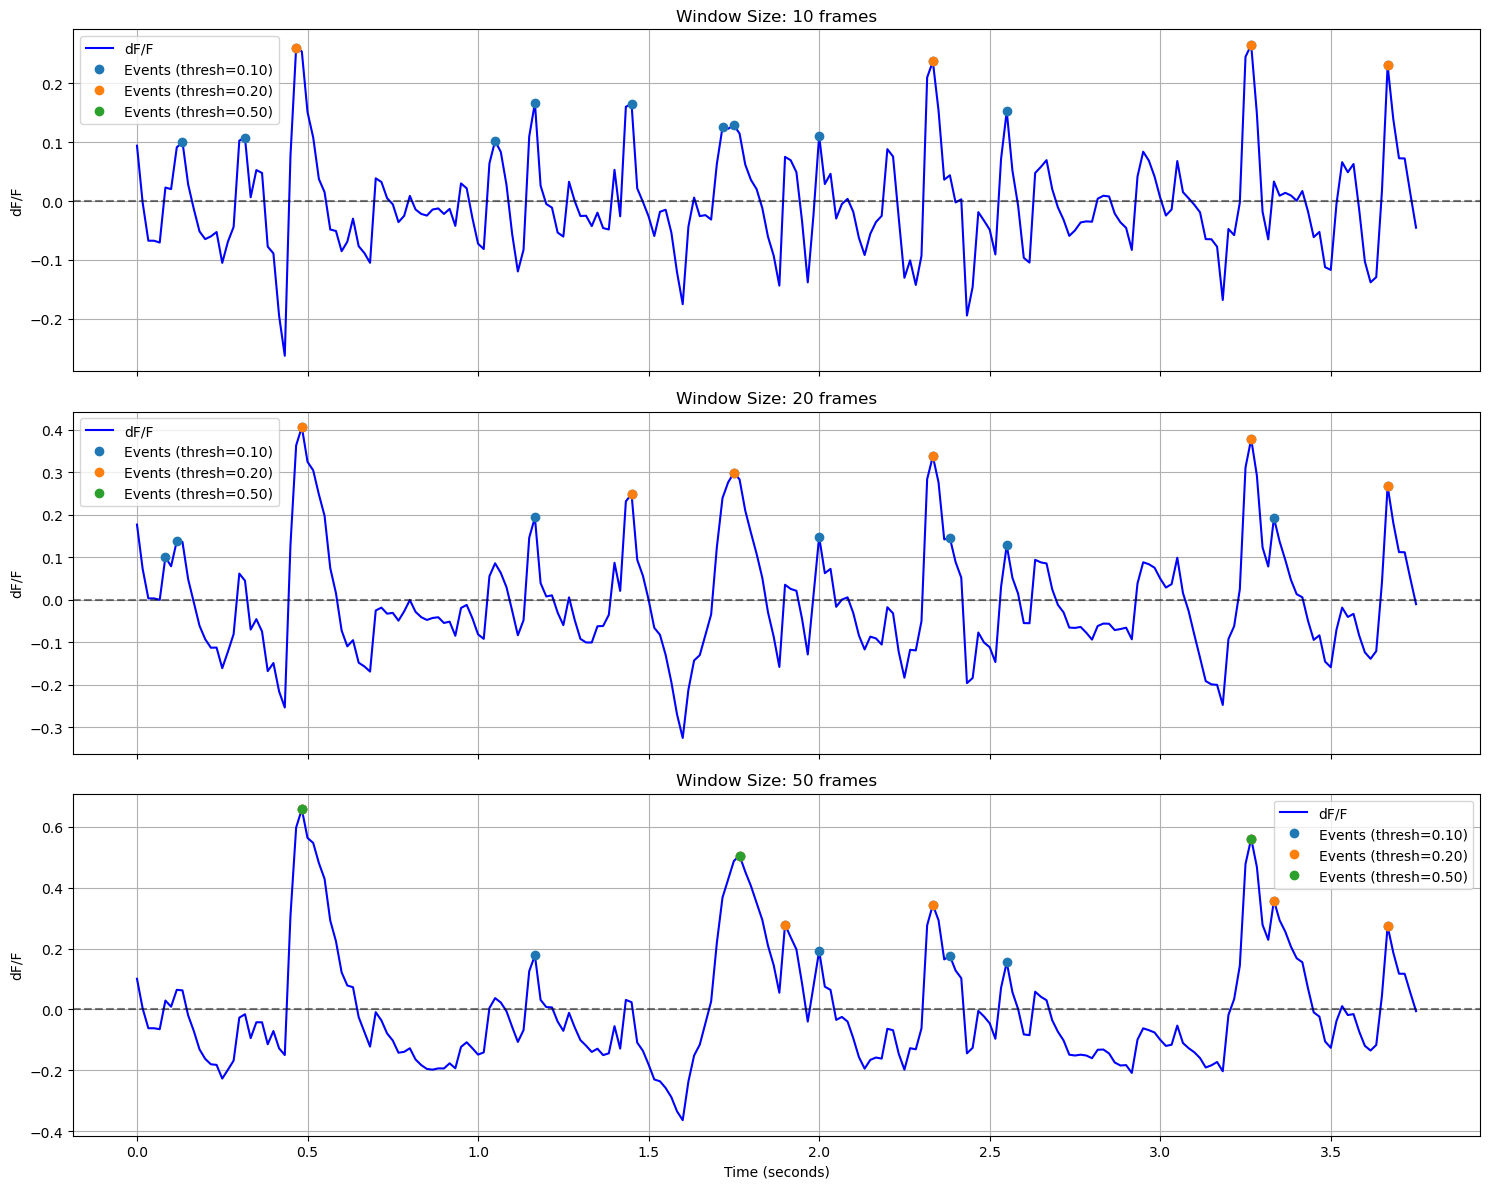

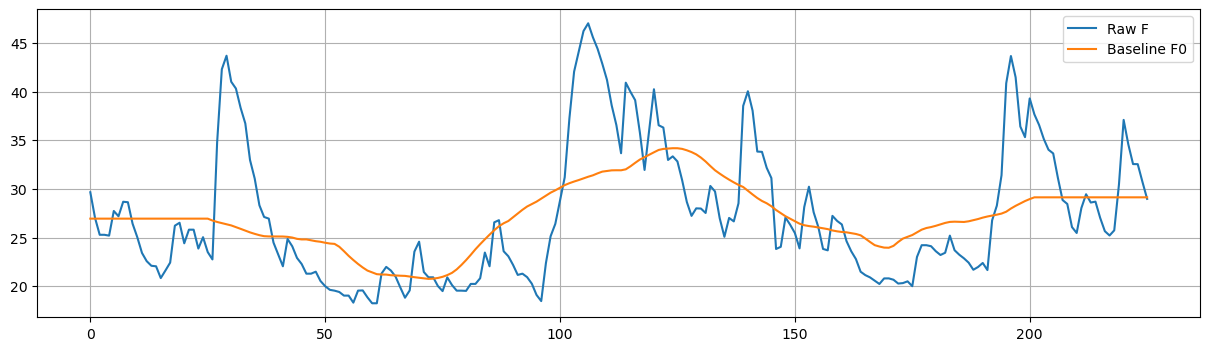

In [40]:
#get frames from screen recording
# Analyze with different parameters
window_sizes = [10, 20, 50]  # frames
thresholds = [0.1, 0.2, 0.5]  # dF/F

F, dff, F0 = analyze_recording(frames, window_sizes, thresholds)

# Plot additional analysis if needed
plt.figure(figsize=(15, 4))
plt.plot(F, label='Raw F')
plt.plot(F0, label='Baseline F0')
plt.legend()
plt.grid(True)
plt.show()

20 frame window  (the actual recording is 20 hz so keep that in mind) 0.2 threshold looks best! 

### Code to screenshot

In [14]:
# take screenshot using pyautogui
image = pyautogui.screenshot()
# this will return the image as PIL object and store in `image` (object oriented functions from PIL avail)

In [15]:
# to save, pass the path of the file as an argument like this
image1 = pyautogui.screenshot(region=(0,0, 300, 400))
save_path = os.path.join(snapshot_dir, "screenshot_test.png")
image1.save(save_path)

In [16]:
#check working directory, if not where ref_image is saved, give full path to locateOnScreen
current_directory = os.getcwd()
print(f"Current Directory: {current_directory}")

Current Directory: c:\Users\emma_odom\Dropbox (MIT)\Emma\Behavior_Code_Emma\snapshot_env


In [25]:
# Find the location of the title on the screen
ref_img_path = os.path.join(snapshot_dir, "ref_image.png")
titleLocation = pyautogui.locateOnScreen(ref_img_path, confidence = 0.7)
#only doesnt fail when confidence is dropped below 0.5, and the coords are wrong so this isnt working. 

In [33]:
titleLocation[1]

np.int64(470)

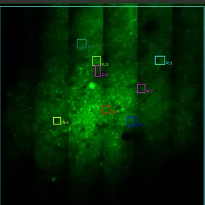

In [48]:
pyautogui.screenshot(region=(int(titleLocation[0])-50,int(titleLocation[1])+30, 205, 205))

In [ ]:
#prints cursor/mouse location continuously
import time

def print_mouse_location():
    try:
        while True:
            x, y = pyautogui.position()
            print(f"Mouse location: ({x}, {y})")
            time.sleep(1)  # Adjust the sleep time as needed
    except KeyboardInterrupt:
        print("Stopped printing mouse location.")

# Call the function to start printing mouse location
print_mouse_location()

Mouse location: (493, 313)
Mouse location: (431, 285)
Mouse location: (339, 168)
Mouse location: (332, 127)
Mouse location: (332, 127)
Mouse location: (332, 127)
Mouse location: (394, 143)
Mouse location: (394, 143)
Mouse location: (333, 120)
Mouse location: (408, 129)
Mouse location: (403, 190)
Mouse location: (538, 537)
Mouse location: (844, 598)
Mouse location: (851, 615)
Mouse location: (1020, 831)
Mouse location: (1225, 802)
Mouse location: (1202, 795)
Mouse location: (1277, 802)
Mouse location: (901, 549)
Mouse location: (551, 353)
Mouse location: (551, 353)
Mouse location: (1118, 343)
Mouse location: (1118, 343)
Mouse location: (442, 162)
Stopped printing mouse location.


### emma has processed up to here

There are sevaral places where improvement is required. 

First, the pyautogui.locate requires an image input, so you can't just give it text to find on the screen. If you want that, you need a more sophisticated method. Or just know it has limited transferability across systems. 

- I think the way to do this would be to use the snapshot feature with a live cropping GUI to save the reference image (used to find imaging fov on screen).

refresh rate is 60 hz on behav pc monitor but i dont know how to get the screen recording to actually line up wioth the refresh bc even if we set it to sample at 60 Hz it might not line up right? or i guess each dislay period should be on for full duration (1000/60) and we will always fall somewhere within that bin, aslong as the display is actually on for the entire period! 

In [69]:
#could be made into a function to get pixel resolution of current monitor. 
from screeninfo import get_monitors

for monitor in get_monitors():
    print("\nMonitor:", monitor.name)
    
    # Method 1: Using dir() to list all attributes and methods
    print("\nAll attributes and methods:")
    for attr in dir(monitor):
        if not attr.startswith('_'):  # Skip internal attributes
            value = getattr(monitor, attr)
            print(f"{attr}: {value}")
    
    # Method 2: Using vars() to show the object's dictionary
    print("\nObject dictionary:")
    print(vars(monitor))


Monitor: \\.\DISPLAY1

All attributes and methods:
height: 1080
height_mm: 296
is_primary: True
name: \\.\DISPLAY1
width: 1920
width_mm: 527
x: 0
y: 0

Object dictionary:
{'x': 0, 'y': 0, 'width': 1920, 'height': 1080, 'width_mm': 527, 'height_mm': 296, 'name': '\\\\.\\DISPLAY1', 'is_primary': True}


In [67]:
def get_monitor_dimensions():
    """
    Returns the width and height of the primary monitor in pixels.
    
    Returns:
        tuple: (width, height) in pixels
    """
    from screeninfo import get_monitors
    
    # Get the first monitor (primary display)
    monitor = get_monitors()[0]
    
    return (monitor.width, monitor.height)

In [68]:
width, height = get_monitor_dimensions()
print(f"Monitor resolution: {width}x{height} pixels")

Monitor resolution: 1920x1080 pixels


### more sophisticated measurement of frame refresh on monitor/display.

In [105]:
def check_frame_refresh(fov, display_live=True, save_frames=False, save_dir=False):
    """
    Record screen synchronized with monitor refresh rate
    Uses frame timing and optional phase adjustment to match monitor refresh
    """
    global live
    live = True
    frames = []
    
    # Get monitor specs
    from screeninfo import get_monitors
    monitor = get_monitors()[0]
    refresh_rate = getattr(monitor, 'refresh_rate', 60)  # Hz
    frame_period = 1.0 / refresh_rate  # seconds
    response_time = 0.005  # Assume 5ms response time, adjust for your monitor
    
    # Calculate timing parameters
    active_display_time = frame_period - response_time
    print(f"Monitor refresh: {refresh_rate}Hz")
    print(f"Frame period: {frame_period*1000:.1f}ms")
    print(f"Estimated active display: {active_display_time*1000:.1f}ms")

    # Phase detection - try to find monitor refresh cycle
    phase_samples = []
    print("Detecting display timing phase...")
    phase_start = time.perf_counter()
    for _ in range(refresh_rate * 2):  # Sample for 2 refresh cycles
        img = pyautogui.screenshot(region=(fov['x'], fov['y'], 1, 1))  # Minimal capture
        phase_samples.append(time.perf_counter())
    
    # Analyze phase timing
    intervals = np.diff(phase_samples)
    mean_interval = np.mean(intervals)
    phase_offset = (phase_samples[0] - phase_start) % frame_period
    print(f"Detected phase offset: {phase_offset*1000:.2f}ms")
    
    # Start keyboard monitor thread
    key_thread = threading.Thread(target=key_monitor)
    key_thread.daemon = True
    key_thread.start()

    # Recording loop with timing
    frame_times = []
    capture_times = []
    missed_frames = 0
    target_frame = 0
    start_time = time.perf_counter()

    while live:
        current_time = time.perf_counter()
        elapsed = current_time - start_time
        
        # Calculate ideal next frame time
        target_frame = int(elapsed / frame_period)
        next_frame_time = start_time + (target_frame * frame_period) + phase_offset
        
        # Wait until just before next frame
        sleep_time = next_frame_time - current_time - 0.001  # 1ms safety margin
        if sleep_time > 0:
            time.sleep(sleep_time)
        
        # Capture frame
        capture_start = time.perf_counter()
        img = pyautogui.screenshot(region=(fov['x'], fov['y'], fov['width'], fov['height']))
        np_img = np.array(img)
        capture_end = time.perf_counter()
        
        # Record timing
        capture_times.append(capture_end - capture_start)
        frame_times.append(capture_end - start_time)
        
        if display_live:
            cv2.imshow('Screen Recording', np_img)
            cv2.waitKey(1)
        
        if save_frames:
            frames.append(np_img)
        
        # Check if we missed a frame
        frame_error = abs((capture_end - next_frame_time) / frame_period)
        if frame_error > 0.5:
            missed_frames += 1
    
    cv2.destroyAllWindows()
    
    # Print performance statistics
    intervals = np.diff(frame_times)
    print("\nRecording Statistics:")
    print(f"Average interval: {np.mean(intervals)*1000:.2f}ms (target: {frame_period*1000:.2f}ms)")
    print(f"Interval std dev: {np.std(intervals)*1000:.2f}ms")
    print(f"Average capture time: {np.mean(capture_times)*1000:.2f}ms")
    print(f"Missed frames: {missed_frames}")
    print(f"Actual frame rate: {1.0/np.mean(intervals):.2f}Hz")
    
    if save_frames and save_dir:
        frames_array = np.array(frames)
        save_path = os.path.join(save_dir, f"recording_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npy")
        np.save(save_path, frames_array)
        print(f"Recording saved to: {save_path}")
    
    return frames if save_frames else None

In [106]:
check_frame_refresh(fov)

Monitor refresh: 60Hz
Frame period: 16.7ms
Estimated active display: 11.7ms
Detecting display timing phase...
Detected phase offset: 3.86ms

Recording Statistics:
Average interval: 72.87ms (target: 16.67ms)
Interval std dev: 12.04ms
Average capture time: 60.53ms
Missed frames: 402
Actual frame rate: 13.72Hz


In [11]:
def get_video_properties(video_path):
    """Get video properties using OpenCV"""
    cap = cv2.VideoCapture(video_path)
    
    # Get properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count/fps
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    cap.release()
    
    print(f"FPS: {fps}")
    print(f"Frame count: {frame_count}")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Resolution: {width}x{height}")
    
    return fps, frame_count, duration, (width, height)

current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'sham_recording.mp4')
fps, frames, duration, resolution = get_video_properties(video_path)

FPS: 60.10624349495141
Frame count: 579
Duration: 9.63 seconds
Resolution: 1280x720


In [116]:
current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'sham_subrecording.mp4')
fps, frames, duration, resolution = get_video_properties(video_path)

FPS: 30.0
Frame count: 289
Duration: 9.63 seconds
Resolution: 1920x1080


In [ ]:
ADD ANOTHER THREAD TO DO THE DF/F AND SEND OUTPUT SERIAL TO ARDUINO OR VIA NIDAQ TO ARDUINO WHICH IS PROBS BETTER :) 

#### cool bc it actually lets you drag and draw a rectangle

In [ ]:
def crop_video_with_gui(video_path, output_path=None):
    """
    GUI tool to crop video while maintaining frame rate.
    Shows first frame for selection, then crops entire video to that region.
    
    Args:
        video_path (str): Path to input video
        output_path (str): Path for output video. If None, creates name automatically
    """
    import cv2
    import numpy as np
    from tkinter import Tk, filedialog
    
    # Global variables for ROI selection
    roi_coords = []
    selecting = False
    
    def mouse_callback(event, x, y, flags, param):
        nonlocal selecting, roi_coords
        if event == cv2.EVENT_LBUTTONDOWN:
            roi_coords = [(x, y)]
            selecting = True
        elif event == cv2.EVENT_MOUSEMOVE and selecting:
            img_copy = first_frame.copy()
            cv2.rectangle(img_copy, roi_coords[0], (x, y), (0, 255, 0), 2)
            cv2.imshow('Select Region', img_copy)
        elif event == cv2.EVENT_LBUTTONUP:
            selecting = False
            roi_coords.append((x, y))
            cv2.rectangle(first_frame, roi_coords[0], roi_coords[1], (0, 255, 0), 2)
            cv2.imshow('Select Region', first_frame)
    
    # Open video and get properties
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Read first frame for selection
    ret, first_frame = cap.read()
    if not ret:
        print("Failed to read video")
        return
    
    # Create window and set mouse callback
    cv2.namedWindow('Select Region')
    cv2.setMouseCallback('Select Region', mouse_callback)
    
    print("Select region by clicking and dragging. Press 'c' to confirm, 'r' to reset.")
    
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('r'):  # Reset selection
            first_frame = first_frame.copy()
            cv2.imshow('Select Region', first_frame)
            roi_coords = []
        elif key == ord('c') and len(roi_coords) == 2:  # Confirm selection
            break
        elif key == ord('q'):  # Quit without cropping
            cap.release()
            cv2.destroyAllWindows()
            return
    
    # Get crop coordinates
    x1, y1 = min(roi_coords[0][0], roi_coords[1][0]), min(roi_coords[0][1], roi_coords[1][1])
    x2, y2 = max(roi_coords[0][0], roi_coords[1][0]), max(roi_coords[0][1], roi_coords[1][1])
    width = x2 - x1
    height = y2 - y1
    
    # Create output path if not provided
    if output_path is None:
        base_path = os.path.splitext(video_path)[0]
        output_path = f"{base_path}_cropped.mp4"
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Process video
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print("\nCropping video...")
    
    for i in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Crop and write frame
        cropped = frame[y1:y2, x1:x2]
        out.write(cropped)
        
        # Progress update
        if i % 100 == 0:
            print(f"Processed {i}/{frame_count} frames")
    
    # Clean up
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    print(f"\nCropped video saved to: {output_path}")
    print(f"Crop dimensions: {width}x{height}")
    print(f"Frame rate maintained at: {fps} fps")
    
    return output_path

# Use it like this:
video_path = os.path.join(current_dir, 'sham_recording.mp4')
cropped_video_path = crop_video_with_gui(video_path)

#### working on checking out frame refresh

In [2]:
def preview_crop(video_path, x1, y1, x2, y2):
    """
    Show preview of cropped first frame from video using provided coordinates.
    
    Args:
        video_path (str): Path to input video
        x1, y1 (int): Top-left coordinates
        x2, y2 (int): Bottom-right coordinates
    """
    # Open video and read first frame
    cap = cv2.VideoCapture(video_path)
    ret, first_frame = cap.read()
    if not ret:
        print("Failed to read video")
        return
    
    # Show original frame
    cv2.imshow('Original Frame', first_frame)
    
    # Crop and show preview
    cropped = first_frame[y1:y2, x1:x2]
    cv2.imshow('Cropped Preview', cropped)
    
    print(f"Original size: {first_frame.shape}")
    print(f"Cropped size: {cropped.shape}")
    
    # Wait for key press
    cv2.waitKey(0)
    
    # Clean up
    cap.release()
    cv2.destroyAllWindows()

In [7]:
current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'screen_record_replay.mp4')
preview_crop(video_path, x1=350, y1=53, x2=980, y2=800)

Original size: (1080, 1888, 3)
Cropped size: (747, 600, 3)


In [8]:
def crop_video_with_preview(video_path, x1, y1, x2, y2, output_path=None):
    """
    Preview crop of first frame and if approved, crop entire video.
    
    Args:
        video_path (str): Path to input video
        x1, y1 (int): Top-left coordinates
        x2, y2 (int): Bottom-right coordinates
        output_path (str): Optional path for output video
    """
    # Open video and get properties
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    ret, first_frame = cap.read()
    if not ret:
        print("Failed to read video")
        return
    
    # Show original and cropped preview
    cv2.imshow('Original Frame', first_frame)
    cropped = first_frame[y1:y2, x1:x2]
    cv2.imshow('Cropped Preview', cropped)
    
    print(f"Original size: {first_frame.shape}")
    print(f"Cropped size: {cropped.shape}")
    print("\nPress 'y' to approve and crop video, or 'n' to cancel")
    
    # Wait for user approval
    while True:
        key = cv2.waitKey(0) & 0xFF
        if key == ord('y'):
            approved = True
            break
        elif key == ord('n'):
            approved = False
            break
    
    cv2.destroyAllWindows()
    
    if not approved:
        print("Cropping cancelled")
        cap.release()
        return
    
    # Create output path if not provided
    if output_path is None:
        base_path = os.path.splitext(video_path)[0]
        output_path = f"{base_path}_cropped.mp4"
    
    # Set up video writer
    width = x2 - x1
    height = y2 - y1
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Process video
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print("\nCropping video...")
    
    # Reset video capture to beginning
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    
    for i in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Crop and write frame
        cropped = frame[y1:y2, x1:x2]
        out.write(cropped)
        
        # Progress update
        if i % 100 == 0:
            print(f"Processed {i}/{frame_count} frames")
    
    # Clean up
    cap.release()
    out.release()
    
    print(f"\nCropped video saved to: {output_path}")
    print(f"Crop dimensions: {width}x{height}")
    print(f"Frame rate: {fps} fps")

In [9]:
current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'screen_record_replay.mp4')
crop_video_with_preview(video_path, x1=350, y1=53, x2=980, y2=800)

Original size: (1080, 1888, 3)
Cropped size: (747, 630, 3)

Press 'y' to approve and crop video, or 'n' to cancel

Cropping video...
Processed 0/758 frames
Processed 100/758 frames
Processed 200/758 frames
Processed 300/758 frames
Processed 400/758 frames
Processed 500/758 frames
Processed 600/758 frames
Processed 700/758 frames

Cropped video saved to: c:\Users\emma_odom\Dropbox (MIT)\Emma\Behavior_Code_Emma\snapshot_env\screen_record_replay_cropped.mp4
Crop dimensions: 630x747
Frame rate: 30.13972426261057 fps


In [13]:
current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'screen_record_replay.mp4')
fps, frames, duration, resolution = get_video_properties(video_path)

FPS: 30.13972426261057
Frame count: 758
Duration: 25.15 seconds
Resolution: 1888x1080


In [16]:
def estimate_frame_rate(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    #read frames into numpy array
    frames = []
    timestamps = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
        timestamps.append(cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0)  # Convert to seconds
    cap.release()

    frames = np.array(frames)
    timestamps = np.array(timestamps)
    frame_diffs = np.diff(frames, axis=0)
    identical_frames = np.where(np.all(frame_diffs == 0, axis=(1,2)))[0] + 1
    
    print("\nAnalysis Results:")
    print(f"Total frames: {frame_count}")
    print(f"MP4 screen record FPS: {fps}")
    print(f"Number of identical consecutive frames: {len(identical_frames)}")
    if len(identical_frames) > 0:
        print(f"Identical frame indices: {identical_frames}")
    
    return identical_frames


In [17]:
current_dir = os.getcwd()
video_path = os.path.join(current_dir, 'screen_record_replay_cropped.mp4')
estimate_frame_rate(video_path)


Analysis Results:
Total frames: 758
MP4 screen record FPS: 30.14
Number of identical consecutive frames: 0


array([], dtype=int64)

Reading 758 frames from c:\Users\emma_odom\Dropbox (MIT)\Emma\Behavior_Code_Emma\snapshot_env\screen_record_replay_cropped.mp4
Nominal FPS: 30.14

Analysis Results:
Total frames analyzed: 757
Duration: 25.15 seconds
Mean difference: 94.41
Max difference: 210.05
Min difference: 1.64
Number of identical consecutive frames: 0


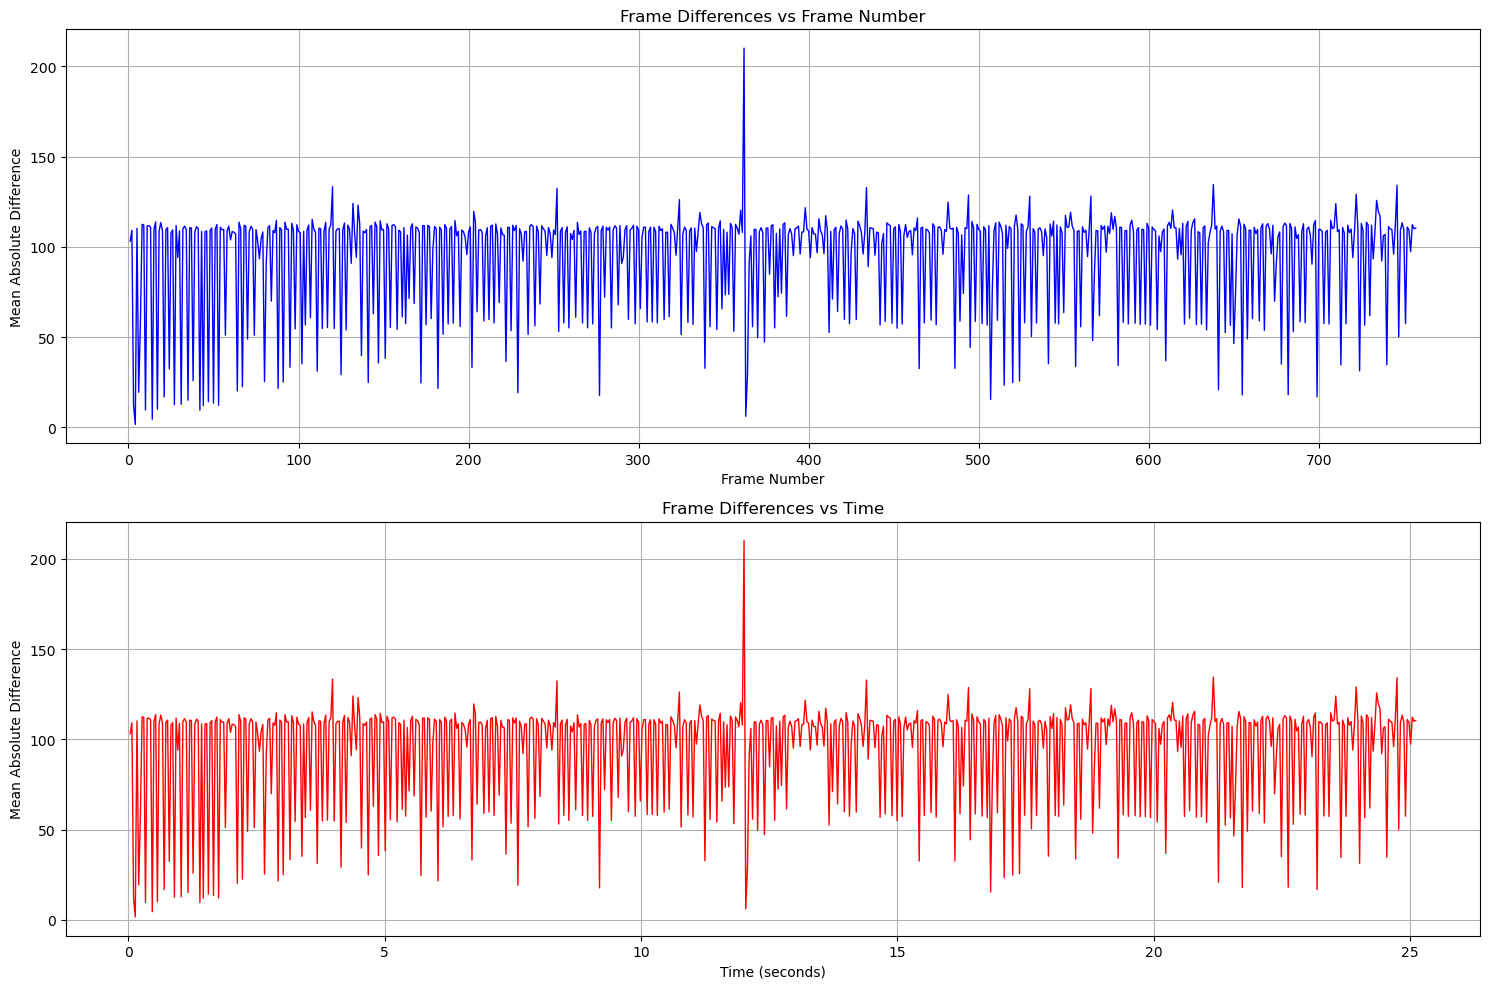

In [21]:
def plot_frame_differences(video_path):
    """
    Read video and plot frame differences against both frame number and time
    
    Args:
        video_path (str): Path to input video file
    """
    # Read video
    cap = cv2.VideoCapture(video_path)
    nominal_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / nominal_fps
    
    # Read frames into numpy array
    frames = []
    print(f"Reading {frame_count} frames from {video_path}")
    print(f"Nominal FPS: {nominal_fps:.2f}")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
    
    cap.release()
    
    # Convert to numpy array and calculate differences
    frames = np.array(frames)
    frame_diffs = np.diff(frames, axis=0)
    mean_diffs = np.mean(np.abs(frame_diffs), axis=(1,2))
    
    # Create arrays for x-axes
    frame_numbers = np.arange(1, len(mean_diffs) + 1)
    time_points = frame_numbers / nominal_fps
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Differences vs Frame Number
    ax1.plot(frame_numbers, mean_diffs, 'b-', linewidth=1)
    ax1.set_title('Frame Differences vs Frame Number')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Mean Absolute Difference')
    ax1.grid(True)
    
    # Plot 2: Differences vs Time
    ax2.plot(time_points, mean_diffs, 'r-', linewidth=1)
    ax2.set_title('Frame Differences vs Time')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Mean Absolute Difference')
    ax2.grid(True)
    
    # Find identical frames (zero difference)
    identical_frames = np.where(mean_diffs == 0)[0] + 1
    
    # Print statistics
    print("\nAnalysis Results:")
    print(f"Total frames analyzed: {len(mean_diffs)}")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Mean difference: {np.mean(mean_diffs):.2f}")
    print(f"Max difference: {np.max(mean_diffs):.2f}")
    print(f"Min difference: {np.min(mean_diffs):.2f}")
    print(f"Number of identical consecutive frames: {len(identical_frames)}")
    
    if len(identical_frames) > 0:
        print(f"\nIdentical frame indices: {identical_frames}")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'frame_numbers': frame_numbers,
        'time_points': time_points,
        'mean_diffs': mean_diffs,
        'identical_frames': identical_frames,
        'nominal_fps': nominal_fps
    }

# Use it like this:
results = plot_frame_differences(video_path)


Frequency Analysis Results:
Nominal recording rate: 30.14 Hz
Expected imaging rate: 23.3 Hz

Dominant frequencies:
0.04 Hz (amplitude: 1431.00)
0.08 Hz (amplitude: 580.21)
0.12 Hz (amplitude: 799.79)
0.20 Hz (amplitude: 1169.37)
0.24 Hz (amplitude: 749.11)
0.28 Hz (amplitude: 455.45)
0.36 Hz (amplitude: 765.10)
0.44 Hz (amplitude: 687.26)
0.56 Hz (amplitude: 465.48)
0.64 Hz (amplitude: 469.53)
0.68 Hz (amplitude: 629.68)
0.72 Hz (amplitude: 634.00)
0.80 Hz (amplitude: 677.63)
0.84 Hz (amplitude: 477.02)
0.88 Hz (amplitude: 542.05)
1.04 Hz (amplitude: 478.70)
1.15 Hz (amplitude: 400.36)
1.31 Hz (amplitude: 417.92)
1.35 Hz (amplitude: 526.56)
1.43 Hz (amplitude: 427.94)
1.51 Hz (amplitude: 1056.58)
1.55 Hz (amplitude: 752.53)
1.67 Hz (amplitude: 408.83)
1.75 Hz (amplitude: 480.20)
1.91 Hz (amplitude: 736.55)
1.99 Hz (amplitude: 599.12)
2.07 Hz (amplitude: 388.43)
2.31 Hz (amplitude: 462.32)
2.35 Hz (amplitude: 639.97)
2.39 Hz (amplitude: 541.26)
2.43 Hz (amplitude: 564.02)
2.47 Hz (ampl

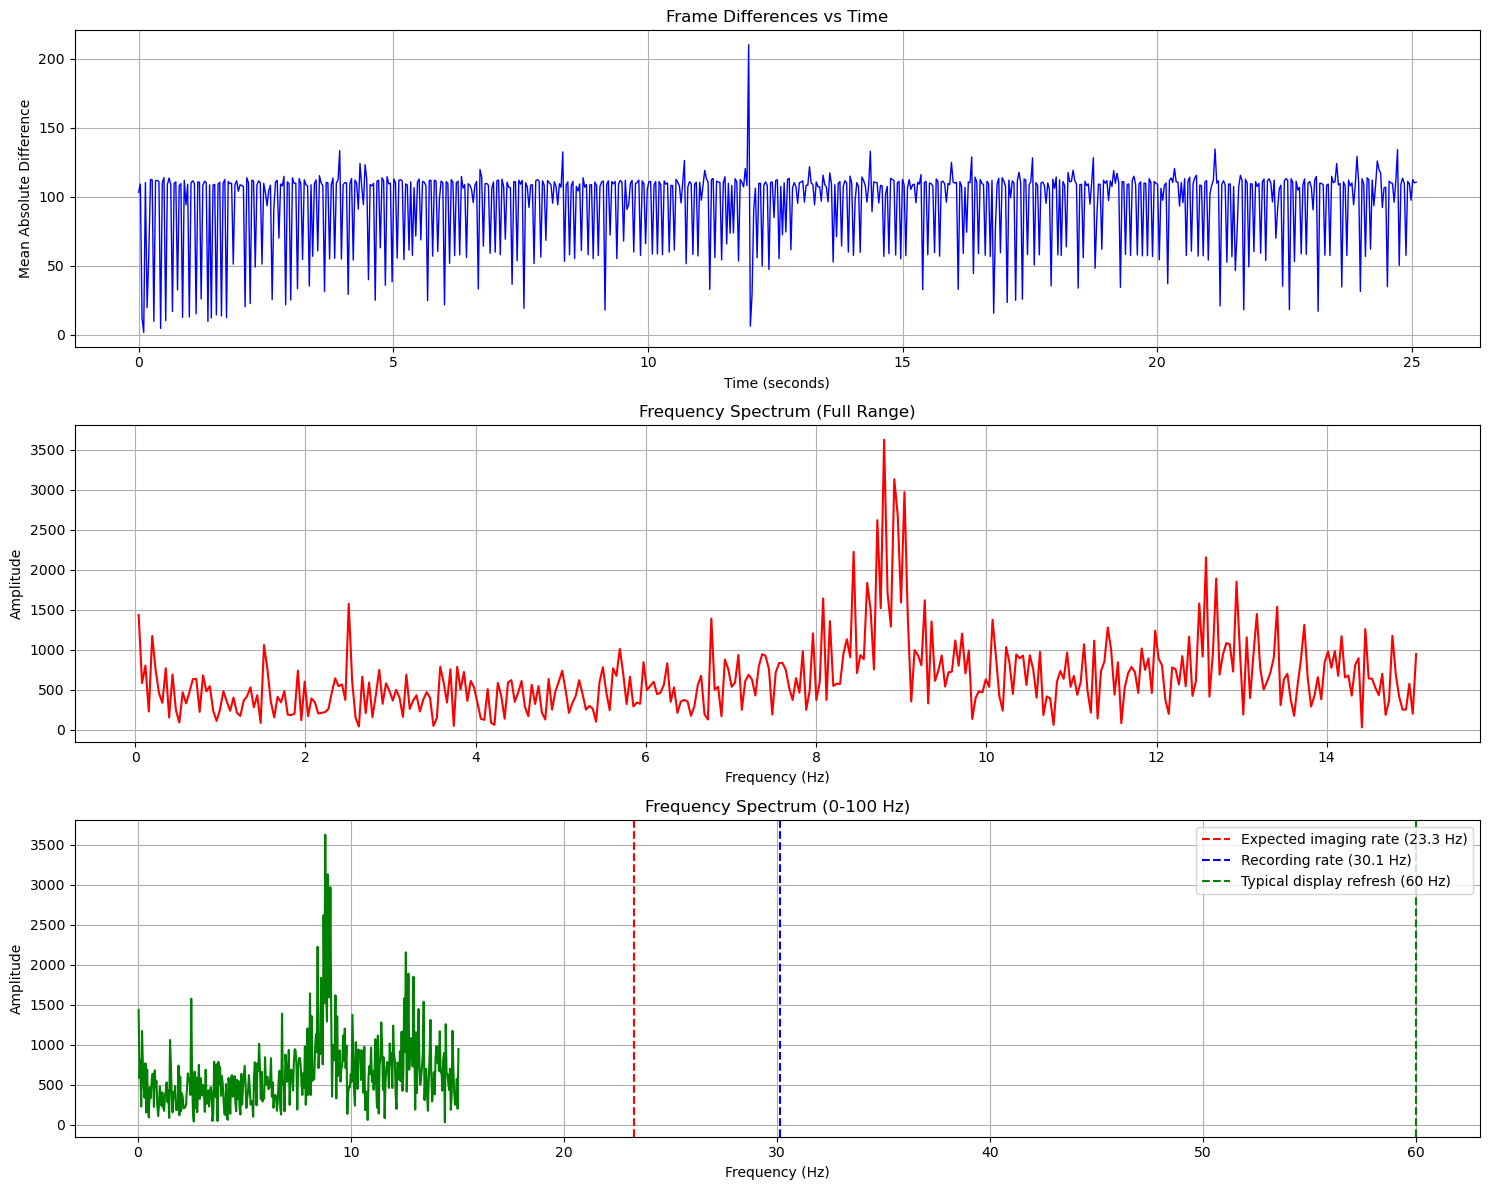

In [22]:
def analyze_video_frequencies(video_path, expected_fps=23):
    """
    Analyze frequency components of frame differences using FFT
    
    Args:
        video_path (str): Path to video file
        expected_fps (float): Expected frame rate of the original imaging
    """
    # Read video and calculate differences (as before)
    cap = cv2.VideoCapture(video_path)
    nominal_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
    
    cap.release()
    
    frames = np.array(frames)
    frame_diffs = np.diff(frames, axis=0)
    mean_diffs = np.mean(np.abs(frame_diffs), axis=(1,2))
    
    # Perform FFT analysis
    from scipy.fft import fft, fftfreq
    
    # Number of samples
    N = len(mean_diffs)
    
    # Sampling period (inverse of recording frame rate)
    T = 1.0 / nominal_fps
    
    # Compute FFT
    yf = fft(mean_diffs - np.mean(mean_diffs))  # Remove DC component
    xf = fftfreq(N, T)  # Frequency bins
    
    # Get positive frequencies only
    pos_freq_mask = xf > 0
    frequencies = xf[pos_freq_mask]
    amplitudes = np.abs(yf[pos_freq_mask])
    
    # Create figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
    
    # Plot 1: Original signal
    time_points = np.arange(len(mean_diffs)) / nominal_fps
    ax1.plot(time_points, mean_diffs, 'b-', linewidth=1)
    ax1.set_title('Frame Differences vs Time')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Mean Absolute Difference')
    ax1.grid(True)
    
    # Plot 2: Full frequency spectrum
    ax2.plot(frequencies, amplitudes, 'r-')
    ax2.set_title('Frequency Spectrum (Full Range)')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True)
    
    # Plot 3: Zoomed frequency spectrum (0-100 Hz)
    mask = frequencies <= 100
    ax3.plot(frequencies[mask], amplitudes[mask], 'g-')
    ax3.set_title('Frequency Spectrum (0-100 Hz)')
    ax3.set_xlabel('Frequency (Hz)')
    ax3.set_ylabel('Amplitude')
    
    # Add vertical lines for expected frequencies
    ax3.axvline(x=expected_fps, color='r', linestyle='--', 
                label=f'Expected imaging rate ({expected_fps} Hz)')
    ax3.axvline(x=nominal_fps, color='b', linestyle='--', 
                label=f'Recording rate ({nominal_fps:.1f} Hz)')
    ax3.axvline(x=60, color='g', linestyle='--', 
                label='Typical display refresh (60 Hz)')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    
    # Find dominant frequencies
    peak_threshold = np.max(amplitudes) * 0.1  # 10% of max amplitude
    peak_indices = np.where(amplitudes > peak_threshold)[0]
    dominant_freqs = frequencies[peak_indices]
    
    print("\nFrequency Analysis Results:")
    print(f"Nominal recording rate: {nominal_fps:.2f} Hz")
    print(f"Expected imaging rate: {expected_fps} Hz")
    print("\nDominant frequencies:")
    for freq, amp in zip(dominant_freqs, amplitudes[peak_indices]):
        if freq <= 100:  # Only show frequencies up to 100 Hz
            print(f"{freq:.2f} Hz (amplitude: {amp:.2f})")
    
    plt.show()
    
    return {
        'frequencies': frequencies,
        'amplitudes': amplitudes,
        'time_points': time_points,
        'mean_diffs': mean_diffs
    }

# Use it like this:
results = analyze_video_frequencies(video_path, expected_fps=23.3)